### 1. 필요한 라이브러리 호출

In [1]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
import random
import time
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm_notebook as tqdm
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

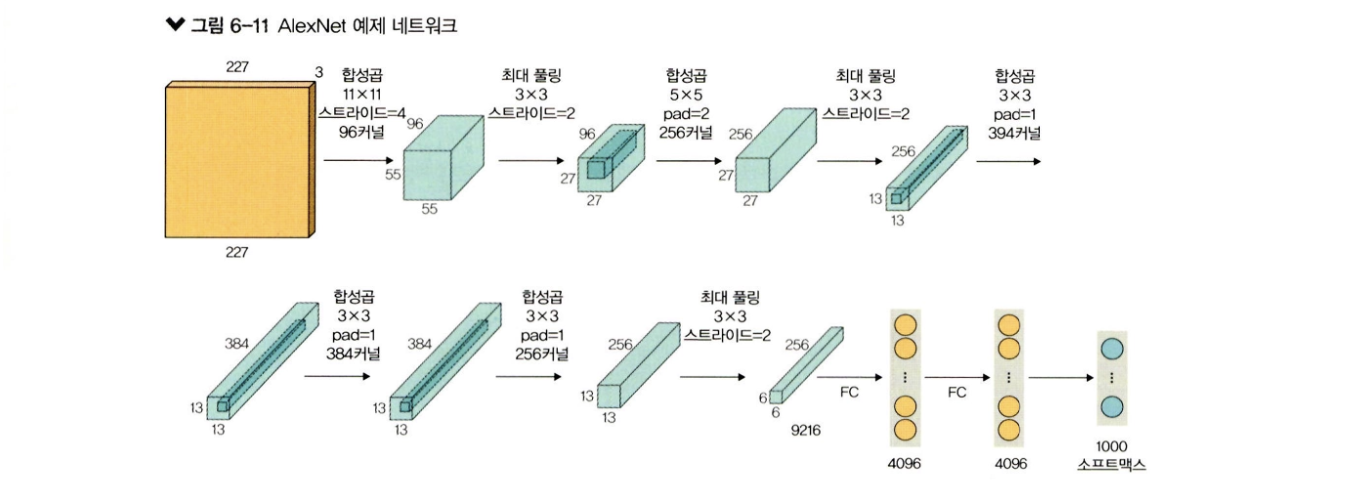

### 2. 데이터 전처리

In [2]:
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase):
        return self.data_transform[phase](img)

### 3. 데이터를 가져와서 훈련, 검증, 테스트 용도로 분리

In [3]:
from google.colab import files
import zipfile
import os

# 파일 업로드 받기
uploaded = files.upload()  # zip 파일 업로드 창이 뜹니다.

# 업로드된 파일의 이름 얻기
filename = next(iter(uploaded))

# 압축 풀기
if filename.endswith(".zip"):
    with zipfile.ZipFile(filename, 'r') as zip_ref:
        zip_ref.extractall('/content')  # 원하는 경로로 압축 해제

Saving dogs-vs-cats.zip to dogs-vs-cats.zip


In [4]:
cat_directory = '/content/Cat/'
dog_directory = '/content/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
#train_images_filepaths = correct_images_filepaths[:20000] #성능을 향상시키고 싶다면 훈련 데이터셋을 늘려서 테스트해보세요
#val_images_filepaths = correct_images_filepaths[20000:-10] #훈련과 함께 검증도 늘려줘야 합니다
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


### 4. 커스텀 데이터셋 정의

In [5]:
class DogvsCatDataset(Dataset):
    def __init__(self, file_list, transform=None, phase='train'):
        self.file_list = file_list # 이미지 데이터가 위치한 파일 경로
        self.transform = transform # 이미지 데이터 전처리
        self.phase = phase # self.phase 는 ImageTransform()에서 정의한 'train'과 'val'을 의미

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx] # 이미지 데이터의 인덱스를 가져오기
        img = Image.open(img_path)
        img_transformed = self.transform(img, self.phase)

        label = img_path.split('/')[-1].split('.')[0] # 레이블 값을 가져오기
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0

        return img_transformed, label

### 5. 변수에 대한 값 정의

- size = 256
  - AlexNet은 깊이가 깊은 네트워크를 사용하므로 이미지 크기가 256이 아니면
풀링층 때문에 크기가 계속 줄어들어 오류가 발생할 수 있습니다.

In [6]:
size = 256
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

### 6. 훈련, 검증, 테스트 테이터셋 정의

- 훈련 데이터셋의 크기는 (3, 256, 256)을 보여 줌
  - 이것에 대한 값은 (채널, 너비, 높이)를 의미

In [7]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


### 7. 데이터셋을 메모리로 불러옴

In [8]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 0, 1, 1, 0, 0, 0])


### 8. AlexNet 모델 네트워크 정의

- AlexNet 모델을 사용하기 위한 네트워크는 사전 훈련된 네트워크와 유사하게 정의
  - 합성곱(Conv2d) + (활성화 함수 (ReLU)) + 풀링(MaxPool2d)이 다섯 번 반복된 후 두 개의 완전연결과 출력층으로 구성된 네트워크

In [9]:
class AlexNet(nn.Module):
    def __init__(self) -> None:
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

- `inplace` 의미 (ReLU 함수 등에서 자주 등장)

  - `inplace=True`는 **기존 데이터를 새로운 값으로 대체**하는 것을 의미함.
  - 즉, 연산 결과를 **새로운 변수에 저장하는 것이 아니라 기존 변수에 덮어쓰기**함.
  - 메모리 효율은 좋아지지만, **기존 값을 덮어쓰므로 원래 값은 사라짐**.

---

- `nn.AdaptiveAvgPool2d`와 `nn.AvgPool2d` 차이

  - `nn.AvgPool2d`:
    - **커널 크기(kernel_size)**, **스트라이드(stride)**, **패딩(padding)** 등을 직접 지정해야 함.
    - 예시: `nn.AvgPool2d((3, 2), stride=(2, 1))`  → 5×5 텐서를 3×3 텐서로, 7×7 텐서를 4×4 텐서로 줄일 수 있음.
    - 입력 텐서 크기: `(N, C, H_in, W_in)`  
    - 출력 텐서 크기: `(N, C, H_out, W_out)`
    - 이때 출력 크기 공식:
      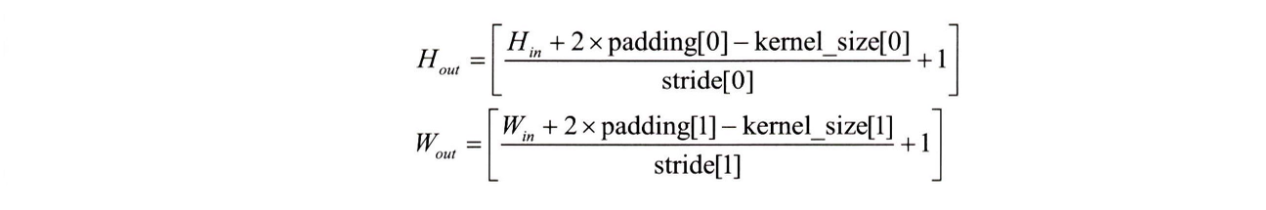

---
- `nn.AdaptiveAvgPool2d`

  - 최종 출력 크기만 지정하면, **자동으로 커널 크기, 스트라이드 등을 계산**해줌.
  - 예: `nn.AdaptiveAvgPool2d((H_out, W_out))`처럼 **출력만 설정하면 끝**!
  - 따라서:
    - 입력 크기가 고정되지 않은 경우에도 **유연하게 사용 가능**
    - CNN 모델 맨 마지막에서 **고정된 출력 크기**로 줄일 때 유용함
  - 완전 연결층(FC layer) 전에 사용하면 좋음.

### 9. model 객체 생성

In [10]:
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

### 10. 옵티마이저 및 손실 함수 정의

In [11]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss().to(device)

### 11. 모델 네트워크 구조 확인

In [12]:
from torchsummary import summary
summary(model, input_size=(3, 256, 256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

### 12. 모델 학습 함수 정의

In [13]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch):
        print('Epoch {}/{}'.format(epoch + 1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            epoch_loss = 0.0
            epoch_corrects = 0

            for inputs, labels in tqdm(dataloader_dict[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    epoch_loss += loss.item() * inputs.size(0)
                    epoch_corrects += torch.sum(preds == labels.data)

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset)
            epoch_acc = epoch_corrects.double() / len(dataloader_dict[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    return model

### 13. 모델 학습

In [14]:
num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


<ipython-input-13-f748dda23cb9>:18: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6934 Acc: 0.4975


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6930 Acc: 0.5435
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6930 Acc: 0.5100


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6929 Acc: 0.5652
Training complete in 9m 21s


### 14. 모델을 이용한 예측

In [15]:
import pandas as pd

id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in tqdm(test_images_filepaths): # 테스트 이미지 데이터 이용
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1] # 이미지 데이터의 번호 가져오기(예를 들어 dog.113.jpg라는 이미지 이름에서 113 가져오기)
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val') # 테스트 데이터에 검증용 전처리 적용
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})
res.to_csv('alexnet.csv', index=False) # 이미지의 id와 레이블을 alexnet.csv 파일에 저장

<ipython-input-15-73d18de0890f>:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/10 [00:00<?, ?it/s]

### 15. 데이터 프레임 결과 확인

In [16]:
res.head(10)

,id,label
0,145,0.500437
1,211,0.501324
2,162,0.501226
3,200,0.501956
4,210,0.501633
5,224,0.500708
6,213,0.500421
7,109,0.501119
8,15,0.500706
9,167,0.500341


### 16. 예측 결과를 시각적으로 표현하기 위한 함수 정의

In [17]:
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]
        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()

### 17. 예측 결과에 대해 이미지와 함께 출력

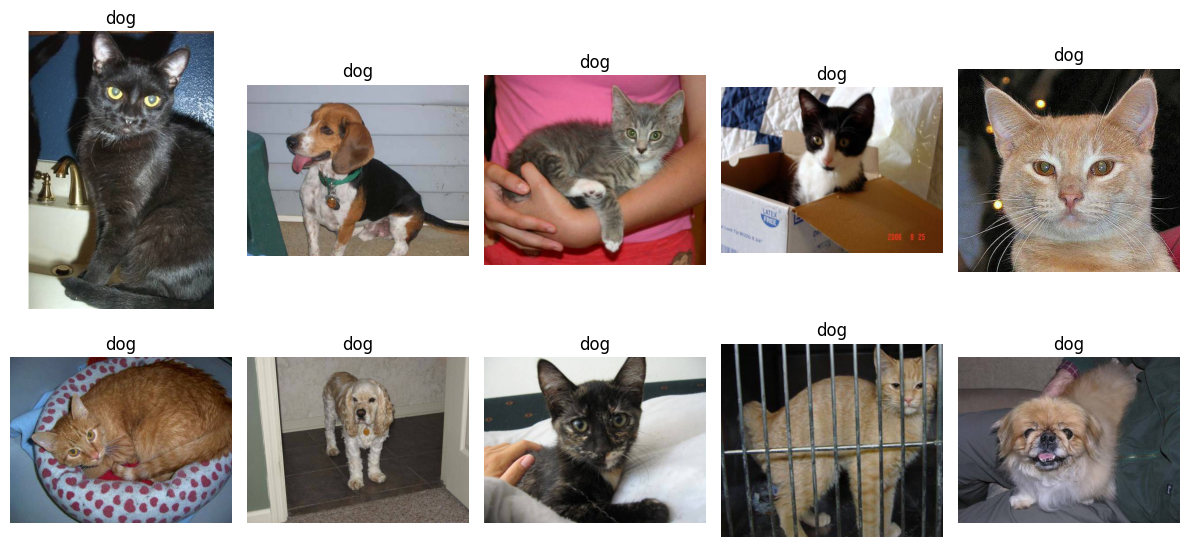

In [18]:
display_image_grid(test_images_filepaths)